In [3]:
 #QUESTION 9

In [6]:

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.graphics.regressionplots import influence_plot


## Load dataset

In [8]:
auto = pd.read_csv(r"C:\Users\DIGITAL AXIS\Desktop\AUTO.CSV")


## Handle missing values in horsepower

In [10]:
auto['horsepower'] = auto['horsepower'].replace('?', np.nan)
auto['horsepower'] = auto['horsepower'].astype(float)


## Drop rows with missing values

In [11]:
auto = auto.dropna()

print(auto.info())

<class 'pandas.core.frame.DataFrame'>
Index: 392 entries, 0 to 396
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           392 non-null    float64
 1   cylinders     392 non-null    int64  
 2   displacement  392 non-null    float64
 3   horsepower    392 non-null    float64
 4   weight        392 non-null    int64  
 5   acceleration  392 non-null    float64
 6   year          392 non-null    int64  
 7   origin        392 non-null    int64  
 8   name          392 non-null    object 
dtypes: float64(4), int64(4), object(1)
memory usage: 30.6+ KB
None



# (a)Scatterplot matrix (pairplot)(All Variables)

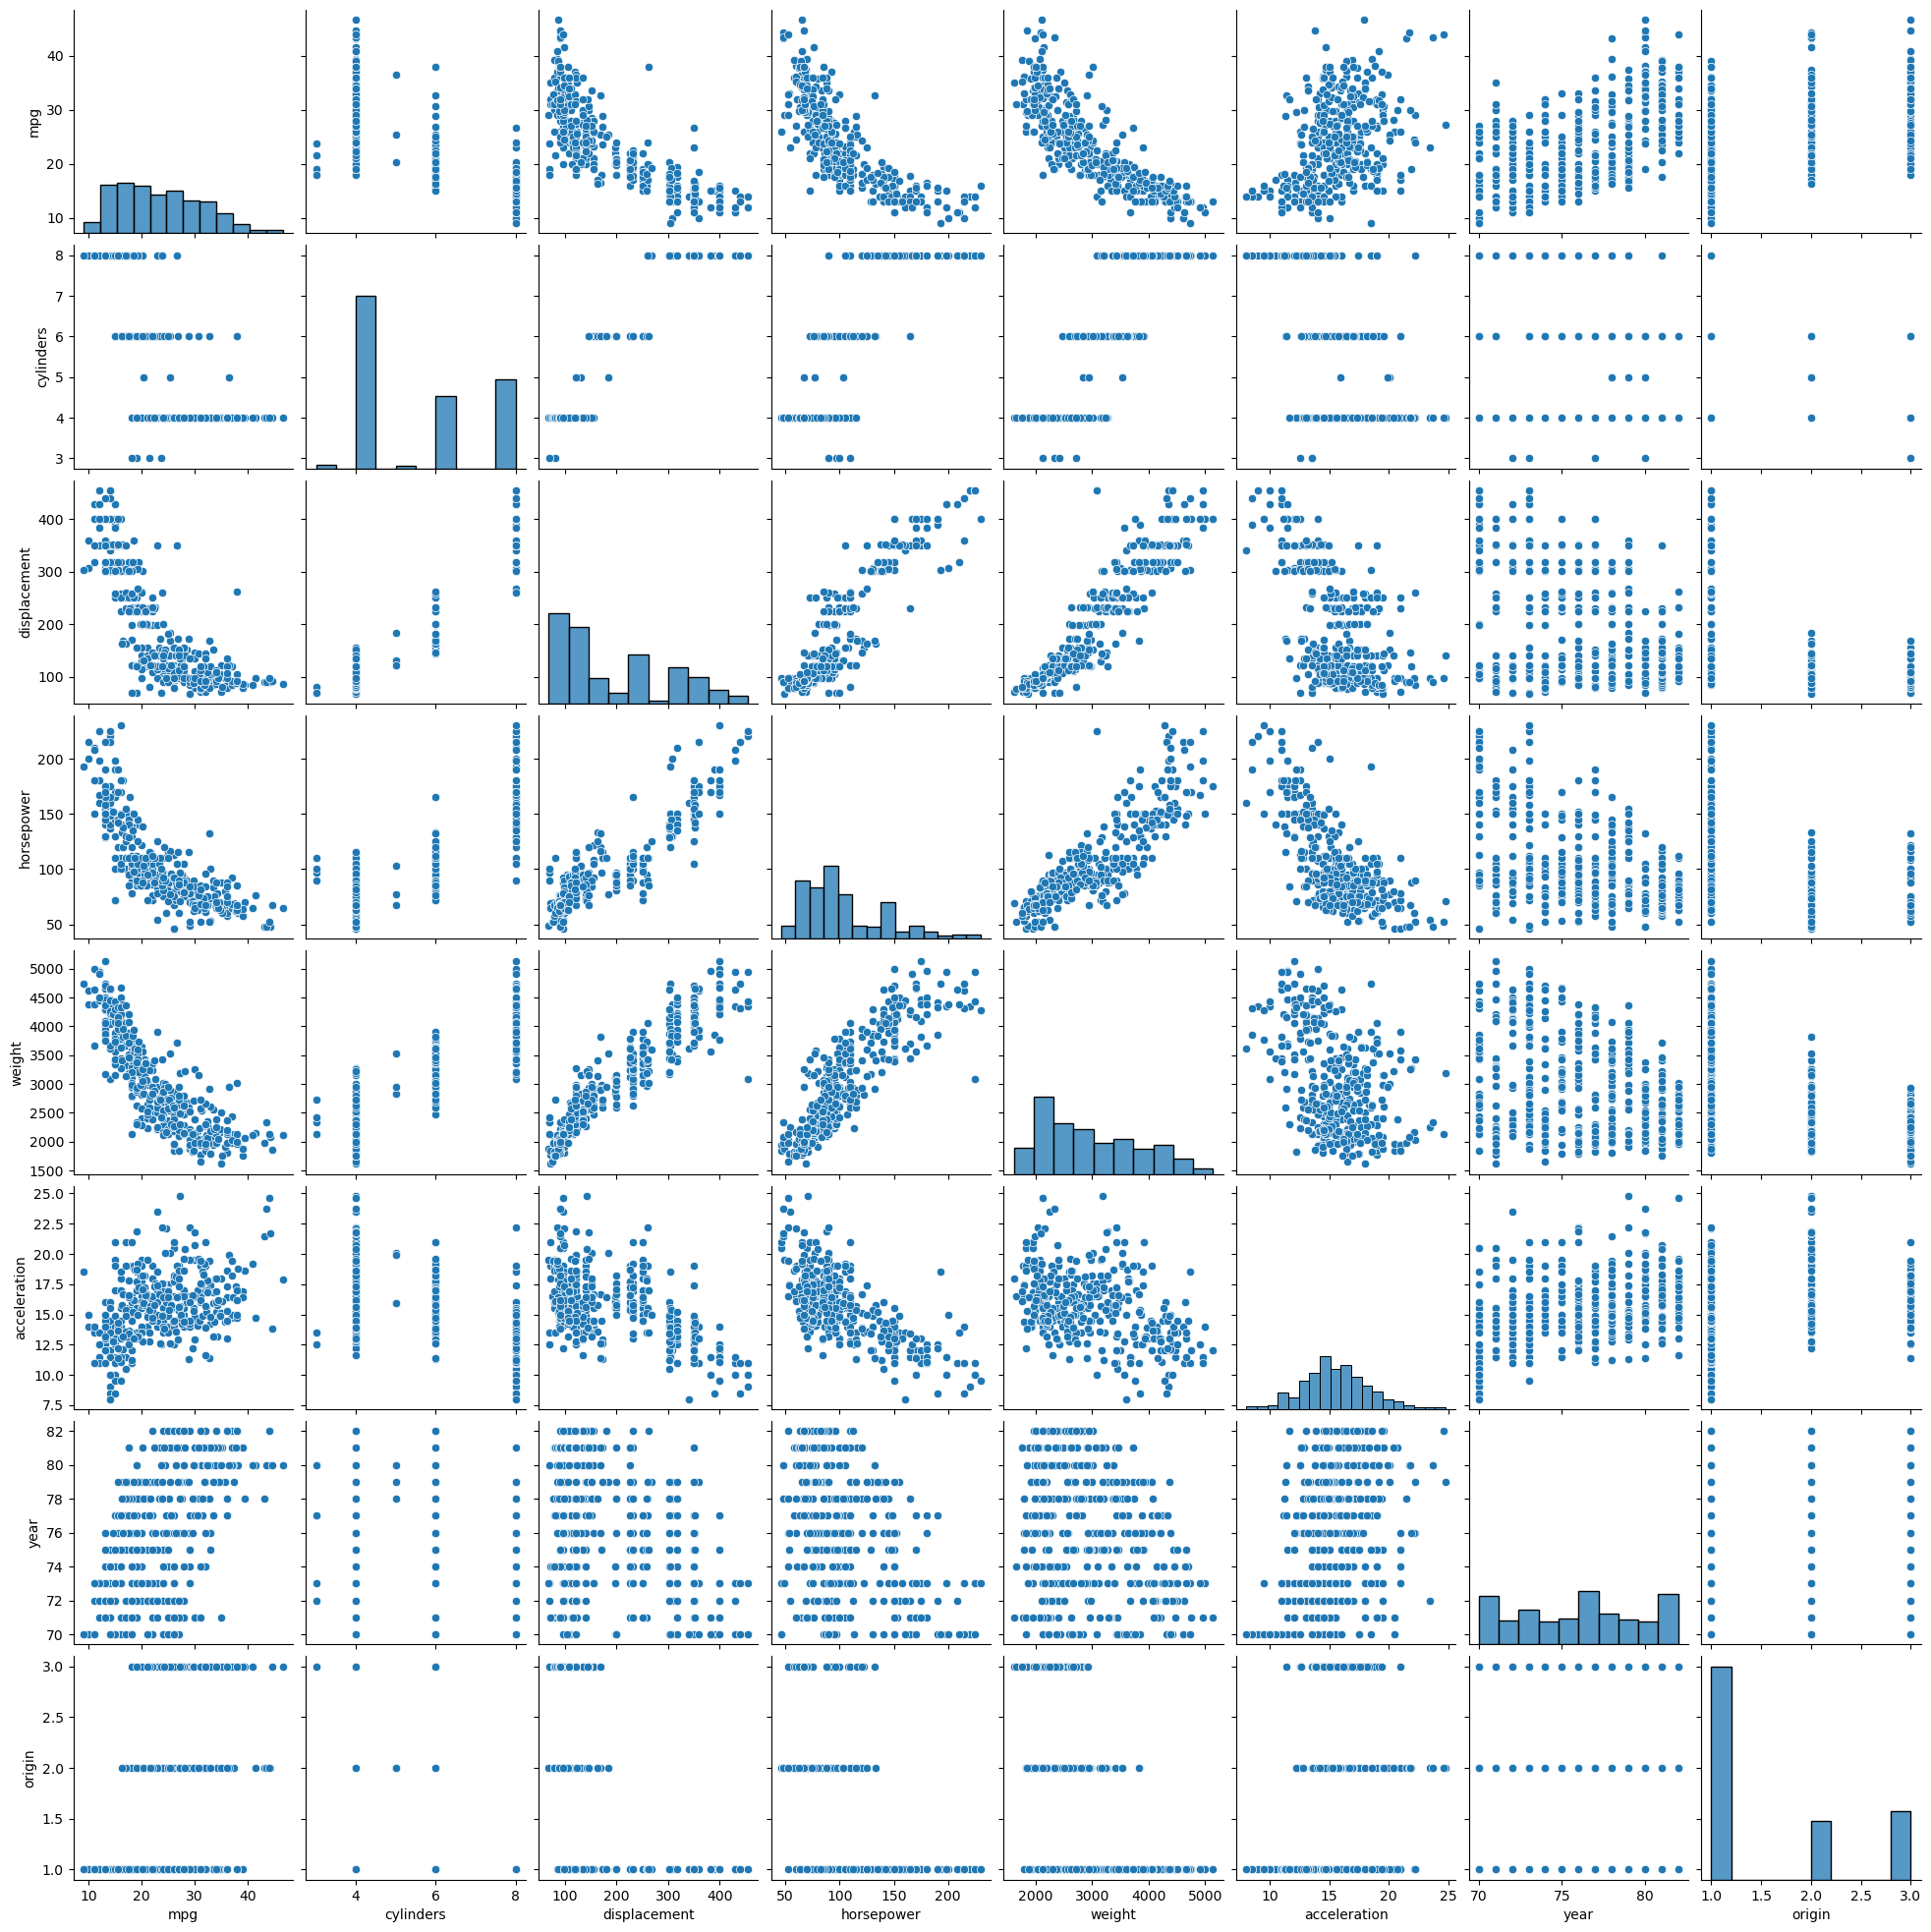

In [12]:
sns.pairplot(auto)
plt.show()

### The scatterplot matrix shows strong negative relationships between mpg
### and variables such as cylinders, displacement, horsepower, and weight.
### Year shows a positive association with mpg.



## (b) Correlation Matrix (Excluding name)Exclude qualitative variable 'name'

In [13]:
auto_numeric = auto.drop(columns=['name'])

### Correlation matrix

In [14]:
corr_matrix = auto_numeric.corr()
print(corr_matrix)

                   mpg  cylinders  displacement  horsepower    weight  \
mpg           1.000000  -0.777618     -0.805127   -0.778427 -0.832244   
cylinders    -0.777618   1.000000      0.950823    0.842983  0.897527   
displacement -0.805127   0.950823      1.000000    0.897257  0.932994   
horsepower   -0.778427   0.842983      0.897257    1.000000  0.864538   
weight       -0.832244   0.897527      0.932994    0.864538  1.000000   
acceleration  0.423329  -0.504683     -0.543800   -0.689196 -0.416839   
year          0.580541  -0.345647     -0.369855   -0.416361 -0.309120   
origin        0.565209  -0.568932     -0.614535   -0.455171 -0.585005   

              acceleration      year    origin  
mpg               0.423329  0.580541  0.565209  
cylinders        -0.504683 -0.345647 -0.568932  
displacement     -0.543800 -0.369855 -0.614535  
horsepower       -0.689196 -0.416361 -0.455171  
weight           -0.416839 -0.309120 -0.585005  
acceleration      1.000000  0.290316  0.212746  

### HeatmaP

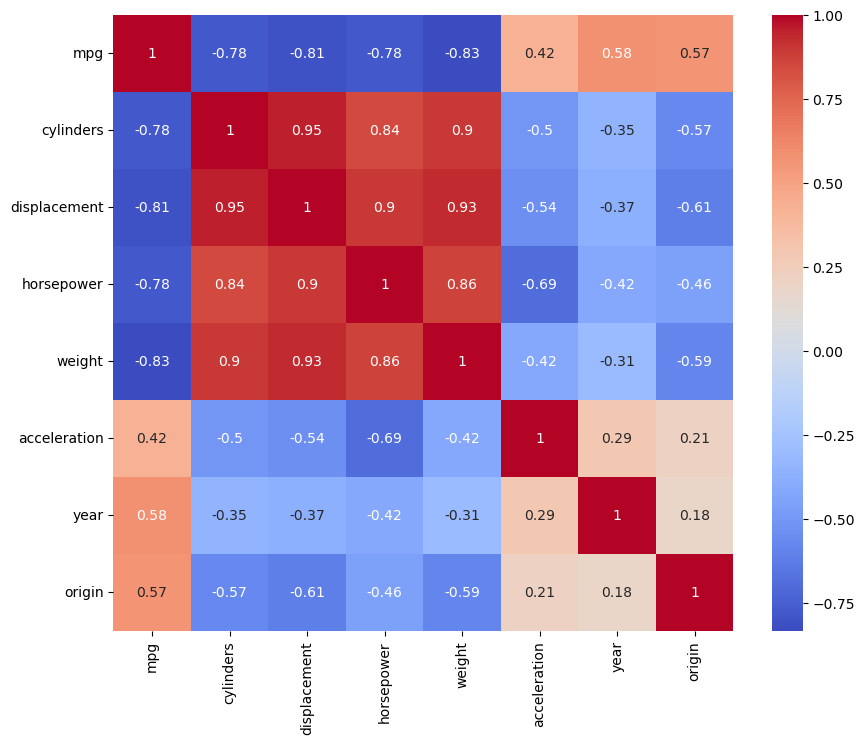

In [15]:
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm")
plt.show()

## mpg is strongly negatively correlated with weight, displacement,
## horsepower, and cylinders, and positively correlated with year.


## (c) Multiple Linear Regression mpg ~ all predictors except nameDefine predictors and response

In [16]:
X = auto_numeric.drop(columns=['mpg'])
y = auto_numeric['mpg']

### Add intercept (equivalent to lm() in R)

In [18]:
X = sm.add_constant(X)

### Fit model

In [19]:
model = sm.OLS(y, X).fit()

### Print summary

In [20]:
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                    mpg   R-squared:                       0.821
Model:                            OLS   Adj. R-squared:                  0.818
Method:                 Least Squares   F-statistic:                     252.4
Date:                Sat, 07 Feb 2026   Prob (F-statistic):          2.04e-139
Time:                        17:05:11   Log-Likelihood:                -1023.5
No. Observations:                 392   AIC:                             2063.
Df Residuals:                     384   BIC:                             2095.
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const          -17.2184      4.644     -3.707   

###(c.i) Is there a relationship between predictors and response?

# The F-statistic p-value tests whether at least one predictor is related to mpg
Answer: Yes — the very small F-statistic p-value (< 0.05) indicates a strong relationship.

(c.ii) Which predictors are statistically significant?
# Look at predictors with p-values < 0.05 in the summary output


Typically significant predictors:

weight

year

displacement / horsepower (depending on multicollinearity)

(c.iii) Interpretation of year coefficient
### The coefficient for 'year' is positive
Interpretation:
For each additional model year, mpg increases, suggesting newer cars are more fuel efficient.

(d) Diagnostic Plots

### Standard diagnostic plots (similar to plot(lm) in R)
fig = plt.figure(figsize=(12, 8))
sm.graphics.plot_regress_exog(model, 'weight', fig=fig)
plt.show()


Residuals vs Fitted

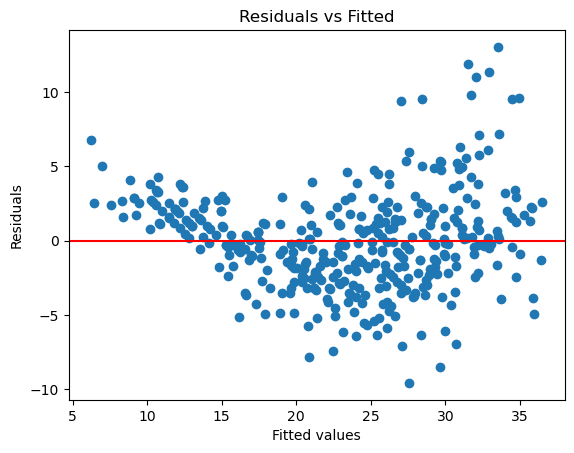

In [21]:
fitted_vals = model.fittedvalues
residuals = model.resid

plt.scatter(fitted_vals, residuals)
plt.axhline(0, color='red')
plt.xlabel("Fitted values")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted")
plt.show()


Leverage Plot

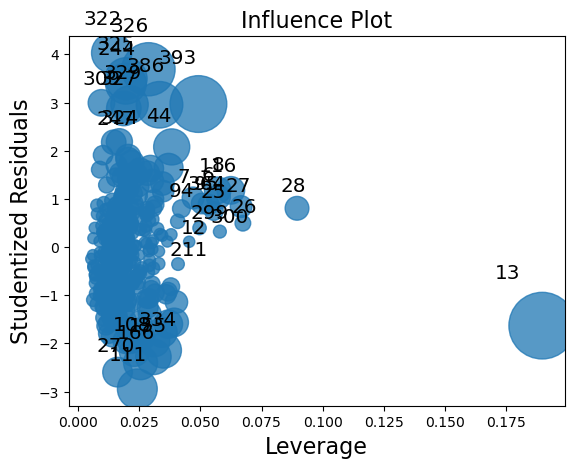

In [22]:
influence_plot(model)
plt.show()


### Residual plots show mild non-linearity and heteroscedasticity.
### A few observations have higher leverage, but no extreme influential outliers.


(e) Interaction Effects (* and :)
Example: horsepower × weight

### Interaction model

In [23]:

auto['hp_weight'] = auto['horsepower'] * auto['weight']

X_int = auto[['horsepower', 'weight', 'hp_weight', 'year']]
X_int = sm.add_constant(X_int)
y = auto['mpg']

interaction_model = sm.OLS(y, X_int).fit()
print(interaction_model.summary())


                            OLS Regression Results                            
Dep. Variable:                    mpg   R-squared:                       0.857
Model:                            OLS   Adj. R-squared:                  0.856
Method:                 Least Squares   F-statistic:                     581.5
Date:                Sat, 07 Feb 2026   Prob (F-statistic):          3.74e-162
Time:                        17:13:03   Log-Likelihood:                -979.51
No. Observations:                 392   AIC:                             1969.
Df Residuals:                     387   BIC:                             1989.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          3.5769      3.911      0.915      0.3

### If the interaction term (hp_weight) has p < 0.05,
### then the effect of horsepower on mpg depends on vehicle weight.


(f) Variable Transformations
(log, square)

Log Transformation

In [25]:
auto['log_weight'] = np.log(auto['weight'])

X_log = auto[['horsepower', 'log_weight', 'year']]
X_log = sm.add_constant(X_log)

log_model = sm.OLS(y, X_log).fit()
print(log_model.summary())


                            OLS Regression Results                            
Dep. Variable:                    mpg   R-squared:                       0.837
Model:                            OLS   Adj. R-squared:                  0.836
Method:                 Least Squares   F-statistic:                     665.6
Date:                Sat, 07 Feb 2026   Prob (F-statistic):          1.46e-152
Time:                        17:14:22   Log-Likelihood:                -1005.3
No. Observations:                 392   AIC:                             2019.
Df Residuals:                     388   BIC:                             2034.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        126.9489      8.291     15.312      0.0

In [ ]:
Polynomial (Quadratic) Term

In [26]:
auto['weight_sq'] = auto['weight'] ** 2

X_poly = auto[['weight', 'weight_sq', 'horsepower', 'year']]
X_poly = sm.add_constant(X_poly)

poly_model = sm.OLS(y, X_poly).fit()
print(poly_model.summary())


                            OLS Regression Results                            
Dep. Variable:                    mpg   R-squared:                       0.852
Model:                            OLS   Adj. R-squared:                  0.851
Method:                 Least Squares   F-statistic:                     557.6
Date:                Sat, 07 Feb 2026   Prob (F-statistic):          3.81e-159
Time:                        17:14:38   Log-Likelihood:                -986.53
No. Observations:                 392   AIC:                             1983.
Df Residuals:                     387   BIC:                             2003.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          4.9966      4.071      1.227      0.2

# Transformations improve model fit (higher R-squared).
# Log(weight) reduces heteroscedasticity.
# Polynomial terms capture non-linear relationships.


### 1. mpg is strongly related to several predictors.
### 2. Weight and year are the most important predictors.
### 3. Newer cars have better fuel efficiency.
### 4. Some non-linearity and mild heteroscedasticity exist.
### 5. Interaction terms can be statistically significant.
### 6. Transformations improve model performance.
